# Social Doors Univariate Second Level Analysis

### Setup

In [1]:
import os
import glob
import pandas as pd
import numpy as np

from matplotlib.gridspec import GridSpec

# Import cerebellum packages
import matplotlib.pyplot as plt
import SUITPy.flatmap as flatmap

from nilearn.glm.second_level import make_second_level_design_matrix
from nilearn.plotting import plot_design_matrix, plot_stat_map
from nilearn.glm.second_level import SecondLevelModel
from nilearn.glm import threshold_stats_img

import importlib

import helpful_functions
importlib.reload(helpful_functions)

<module 'helpful_functions' from '/Volumes/HP-SOC-DOOR/social_doors/code/helpful_functions.py'>

In [2]:
#bids_dir = '/data/projects/social_doors/'
bids_dir = '/Volumes/HP-SOC-DOOR/social_doors/'


os.chdir(bids_dir)

data_dir = os.path.join(bids_dir, 'derivatives','social_doors-nilearn')
outp_dir = os.path.join(bids_dir, 'derivatives', 'social_doors-nilearn')


# Define subject list
#subjs_scan_info = pd.read_csv(bids_dir+'/derivatives/mriqc/mriqc_summary_poor.csv')
#subjs_list = list(subjs_scan_info['subject'].unique())
#subjs_list.sort()
subjs_info = pd.read_csv(bids_dir+'/derivatives/participants_good.tsv', sep='\t', index_col=0)
subjs_info = subjs_info.rename(columns={'participant_id': 'subject_label'})

# Remove participants with bad data
subjs_info = subjs_info[subjs_info['subject_label'].str.contains('sub-3880')==False]
subjs_info = subjs_info[subjs_info['subject_label'].str.contains('sub-4069')==False]


subjs_info_kids = subjs_info[subjs_info['group']=='kid']
subjs_info_colg = subjs_info[subjs_info['group']=='college']

subjs_list = subjs_info['subject_label'].to_list()
subjs_list_kids = subjs_info_kids['subject_label'].to_list()
subjs_list_colg = subjs_info_colg['subject_label'].to_list()

print('Found '+str(len(subjs_list_kids))+' adolescent subjects')
print('Found '+str(len(subjs_list_colg))+' college subjects')

Found 32 adolescent subjects
Found 29 college subjects


## Adolescents

In [3]:
# Filter for releveant data
subjs_info_fltr = subjs_info[['subject_label', 'age']]
subjs_info_kids_fltr = subjs_info_kids[['subject_label','age']]
subjs_info_colg_fltr = subjs_info_colg[['subject_label','age']]

/opt/anaconda3/lib/python3.11/site-packages/nilearn/glm/first_level/design_matrix.py:531: UserWarning: Attention: Design matrix is singular. Aberrant estimates are expected.
  warn(


<Axes: label='conditions', ylabel='scan number'>

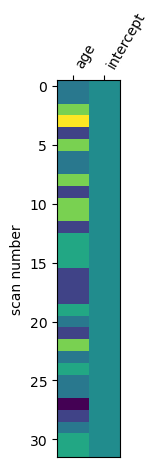

In [4]:
design_matrix = make_second_level_design_matrix(subjs_list_kids, subjs_info_kids_fltr)

plot_design_matrix(design_matrix)

In [ ]:
def calc_second_level(group, subjs_list, task, contrast, contrasts_2nd, space):

    if not space:
        # Collect data in default space
        temp_file_list = []
        for subj in subjs_list:
            temp_file = glob.glob(os.path.join(data_dir,subj,'zmap_'+task+'_'+contrast+'.nii.gz'))
            temp_file_list.append(temp_file[0])
        temp_file_list.sort()

        mask = bids_dir+"/derivatives/fmriprep/sub-010/anat/sub-010_space-MNI152NLin2009cAsym_label-GM_probseg_bin.nii.gz"
    
    if space == 'SUIT':
        # Collect cerebellum data in SUIT space
        temp_file_list = []
        for subj in subjs_list:
            temp_file = glob.glob(os.path.join(data_dir,subj,'zmap_'+task+'_'+contrast+'_space-SUIT.nii.gz'))
            temp_file_list.append(temp_file[0])
        temp_file_list.sort()

        mask = 

        
    print('Calculating '+task+' '+group+' '+contrast+' contrast')
    
    # Fit the second level GLM
    model = SecondLevelModel(mask_img=mni_mask, smoothing_fwhm=8.0)
    model.fit(temp_file_list, design_matrix=design_matrix)
    
    for contrast_2nd in contrasts_2nd:
        # Compute a specific contrast (e.g. pos reward vs neg reward)
        contrast_stats = model.compute_contrast(contrast_2nd, output_type='all')
        
        # Save the z-score stat map and the effect size map
        z_map = contrast_stats['z_score']
        e_map = contrast_stats['effect_size']
    
        z_map.to_filename(os.path.join(data_dir,'group',
                                   group+'_'+task+'_'+contrast+'_'+contrast_2nd+'_zmap.nii.gz'))
        e_map.to_filename(os.path.join(data_dir,'group',
                                   group+'_'+task+'_'+contrast+'_'+contrast_2nd+'_effect.nii.gz'))
    
        
        # Multiple Comparisons Correction
        z_map_thresh, threshold = threshold_stats_img(z_map, alpha=alpha, height_control=mc)
        z_map_thresh.to_filename(os.path.join(data_dir,'group',
                                   group+'_'+task+'_'+contrast+'_'+contrast_2nd+'_zmap_'+mc+'-'+str(alpha)+'.nii.gz'))

In [6]:
design_matrix = make_second_level_design_matrix(subjs_list_kids, subjs_info_kids_fltr)
mni_mask = bids_dir+"/derivatives/fmriprep/sub-010/anat/sub-010_space-MNI152NLin2009cAsym_label-GM_probseg_bin.nii.gz"

#contrasts = ['valence_x_outcome',
#             'positive','positive_win','positive_loss',
#             'negative','negative_win','negative_loss']
contrasts = ['positive_winVlos', 'negative_winVlos', 'posVneg_win']
contrasts_2nd = ['age','intercept']
tasks = ['mdoors','social']
group = 'adole'
mc = 'fdr'
alpha = 0.05


for task in tasks:
    for contrast in contrasts:

        # Conduct cerebrum analysis
        temp_file_list = []
        for subj in subjs_list_kids:
            temp_file = glob.glob(os.path.join(data_dir,subj,'zmap_'+task+'_'+contrast+'.nii.gz'))
            temp_file_list.append(temp_file[0])
        temp_file_list.sort()
        
        print('Calculating '+task+' '+group+' '+contrast+' contrast')
        
        # Fit the second level GLM
        model = SecondLevelModel(mask_img=mni_mask, smoothing_fwhm=8.0)
        model.fit(temp_file_list, design_matrix=design_matrix)
        
        for contrast_2nd in contrasts_2nd:
            # Compute a specific contrast (e.g. pos reward vs neg reward)
            contrast_stats = model.compute_contrast(contrast_2nd, output_type='all')
            
            # Save the z-score stat map and the effect size map
            z_map = contrast_stats['z_score']
            e_map = contrast_stats['effect_size']

            z_map.to_filename(os.path.join(data_dir,'group',
                                       group+'_'+task+'_'+contrast+'_'+contrast_2nd+'_zmap.nii.gz'))
            e_map.to_filename(os.path.join(data_dir,'group',
                                       group+'_'+task+'_'+contrast+'_'+contrast_2nd+'_effect.nii.gz'))

            
            # Multiple Comparisons Correction
            z_map_thresh, threshold = threshold_stats_img(z_map, alpha=alpha, height_control=mc)
            z_map_thresh.to_filename(os.path.join(data_dir,'group',
                                       group+'_'+task+'_'+contrast+'_'+contrast_2nd+'_zmap_'+mc+'-'+str(alpha)+'.nii.gz'))
            


        # Conduct cerebellum analysis in SUIT space
            

/opt/anaconda3/lib/python3.11/site-packages/nilearn/glm/first_level/design_matrix.py:531: UserWarning: Attention: Design matrix is singular. Aberrant estimates are expected.
  warn(


Calculating mdoors adole all_winVlos contrast
Calculating mdoors adole positive_winVlos contrast


/opt/anaconda3/lib/python3.11/site-packages/nilearn/glm/thresholding.py:303: UserWarning: The given float value must not exceed 3.9788959272588595. But, you have given threshold=inf.
  stat_img = threshold_img(
/opt/anaconda3/lib/python3.11/site-packages/nilearn/glm/thresholding.py:303: UserWarning: The given float value must not exceed 3.967129421088635. But, you have given threshold=inf.
  stat_img = threshold_img(


Calculating mdoors adole negative_winVlos contrast


/opt/anaconda3/lib/python3.11/site-packages/nilearn/glm/thresholding.py:303: UserWarning: The given float value must not exceed 3.842956121103654. But, you have given threshold=inf.
  stat_img = threshold_img(
/opt/anaconda3/lib/python3.11/site-packages/nilearn/glm/thresholding.py:303: UserWarning: The given float value must not exceed 3.845004626660831. But, you have given threshold=inf.
  stat_img = threshold_img(


...

/opt/anaconda3/lib/python3.11/site-packages/nilearn/glm/thresholding.py:303: UserWarning: The given float value must not exceed 3.5051994155312776. But, you have given threshold=inf.
  stat_img = threshold_img(
/opt/anaconda3/lib/python3.11/site-packages/nilearn/glm/thresholding.py:303: UserWarning: The given float value must not exceed 3.6068468901047095. But, you have given threshold=inf.
  stat_img = threshold_img(


Calculating social adole negative_winVlos contrast


/opt/anaconda3/lib/python3.11/site-packages/nilearn/glm/thresholding.py:303: UserWarning: The given float value must not exceed 3.761604455639194. But, you have given threshold=inf.
  stat_img = threshold_img(
/opt/anaconda3/lib/python3.11/site-packages/nilearn/glm/thresholding.py:303: UserWarning: The given float value must not exceed 3.832991405397117. But, you have given threshold=inf.
  stat_img = threshold_img(


Calculating social adole posVneg_win contrast


/opt/anaconda3/lib/python3.11/site-packages/nilearn/glm/thresholding.py:303: UserWarning: The given float value must not exceed 4.001141345104995. But, you have given threshold=inf.
  stat_img = threshold_img(
/opt/anaconda3/lib/python3.11/site-packages/nilearn/glm/thresholding.py:303: UserWarning: The given float value must not exceed 4.0411935227993965. But, you have given threshold=inf.
  stat_img = threshold_img(


### Monetary Task

#### Positive win > Positive loss

/opt/anaconda3/lib/python3.11/site-packages/nilearn/plotting/displays/_slicers.py:366: UserWarning: empty mask
  self._map_show(img, type="contour", threshold=threshold, **kwargs)
/opt/anaconda3/lib/python3.11/site-packages/nilearn/plotting/displays/_slicers.py:366: UserWarning: empty mask
  self._map_show(img, type="contour", threshold=threshold, **kwargs)


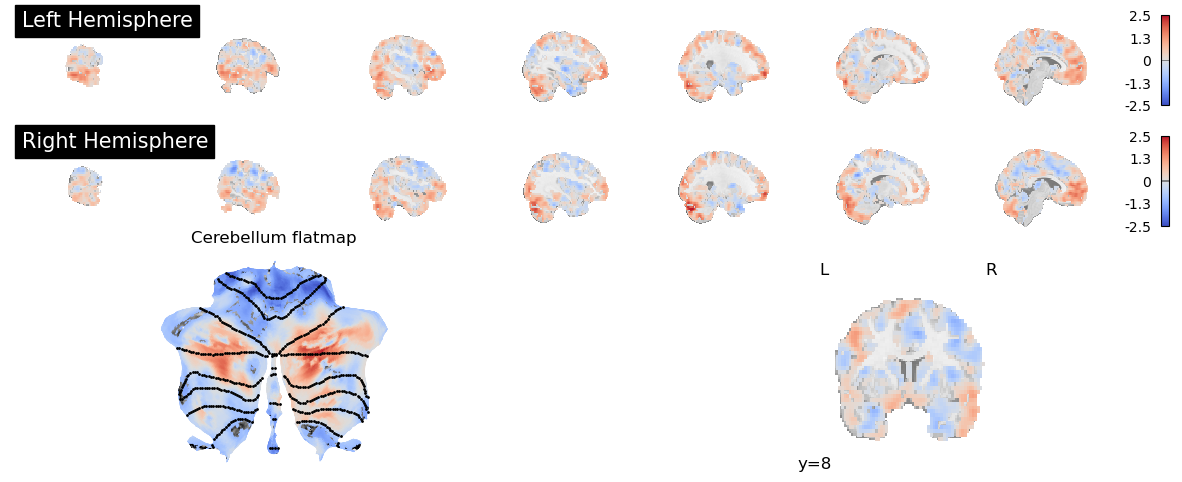

In [7]:
filename = data_dir+'/group/'+'adole_mdoors_positive_winVlos_intercept'

helpful_functions.plot_transparent_threshold(filename, thresh=.05)

#### All wins > All losses

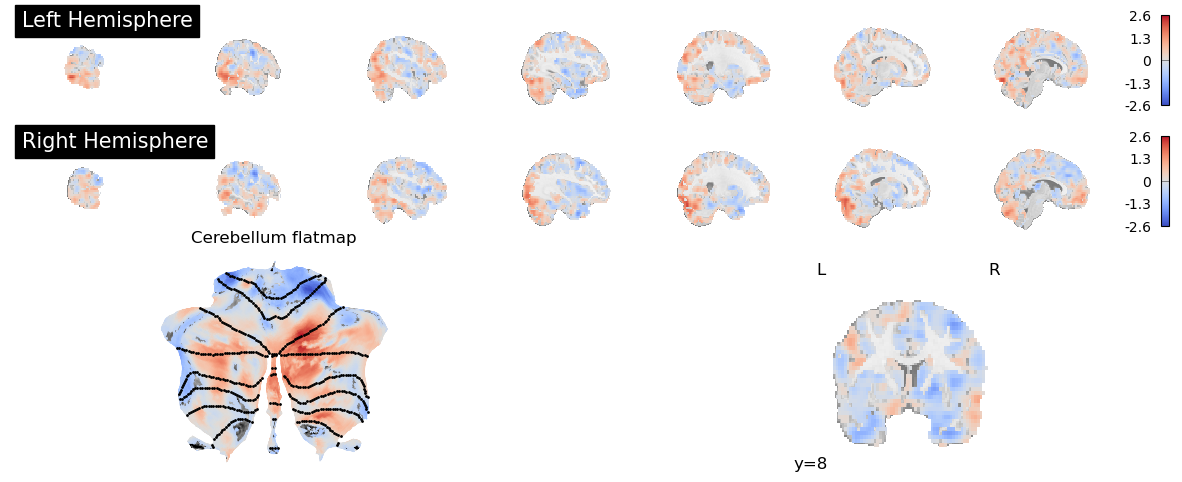

In [8]:
filename = data_dir+'/group/'+'adole_mdoors_all_winVlos_intercept'

helpful_functions.plot_transparent_threshold(filename, thresh=.05)

#### Positive wins > Negative wins

/opt/anaconda3/lib/python3.11/site-packages/nilearn/plotting/displays/_slicers.py:366: UserWarning: empty mask
  self._map_show(img, type="contour", threshold=threshold, **kwargs)
/opt/anaconda3/lib/python3.11/site-packages/nilearn/plotting/displays/_slicers.py:366: UserWarning: empty mask
  self._map_show(img, type="contour", threshold=threshold, **kwargs)


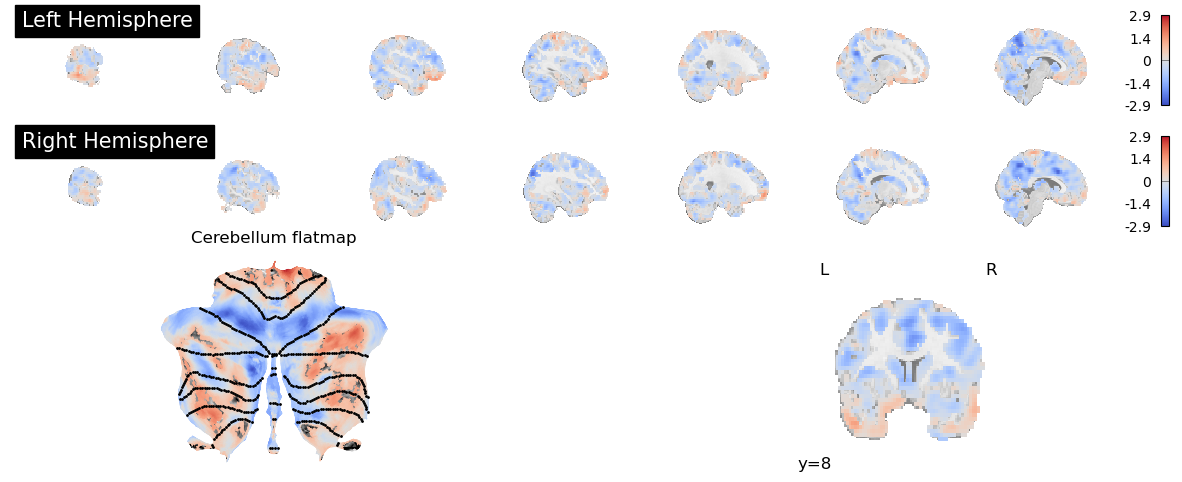

In [9]:
filename = data_dir+'/group/'+'adole_mdoors_posVneg_win_intercept'

helpful_functions.plot_transparent_threshold(filename, thresh=.05)

### Social Task

#### Positive win > Positive loss

/opt/anaconda3/lib/python3.11/site-packages/nilearn/plotting/displays/_slicers.py:366: UserWarning: empty mask
  self._map_show(img, type="contour", threshold=threshold, **kwargs)
/opt/anaconda3/lib/python3.11/site-packages/nilearn/plotting/displays/_slicers.py:366: UserWarning: empty mask
  self._map_show(img, type="contour", threshold=threshold, **kwargs)


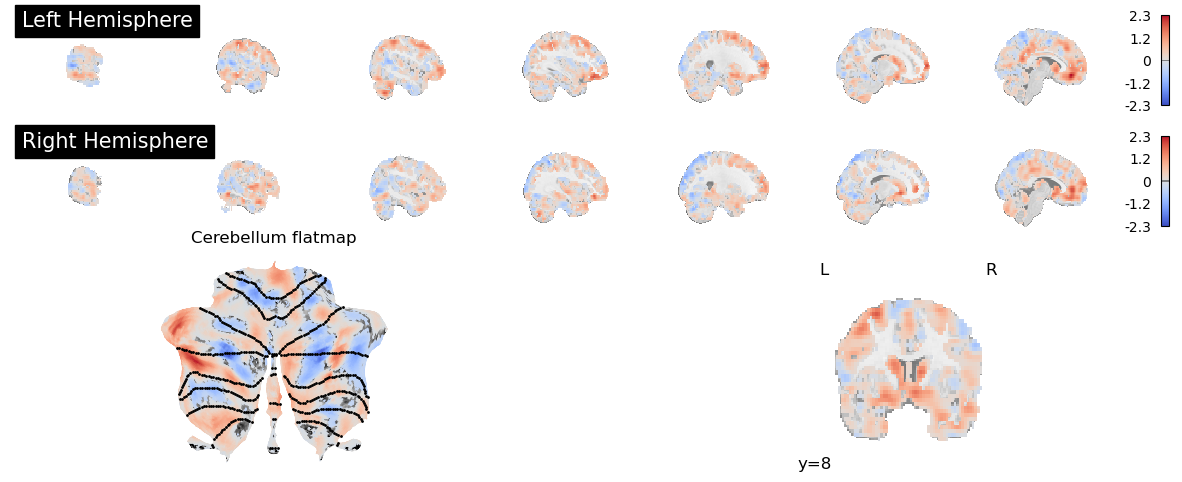

In [10]:
filename = data_dir+'/group/'+'adole_social_positive_winVlos_intercept'

helpful_functions.plot_transparent_threshold(filename, thresh=.05)

#### All wins > All losses

/opt/anaconda3/lib/python3.11/site-packages/nilearn/plotting/displays/_slicers.py:366: UserWarning: empty mask
  self._map_show(img, type="contour", threshold=threshold, **kwargs)
/opt/anaconda3/lib/python3.11/site-packages/nilearn/plotting/displays/_slicers.py:366: UserWarning: empty mask
  self._map_show(img, type="contour", threshold=threshold, **kwargs)


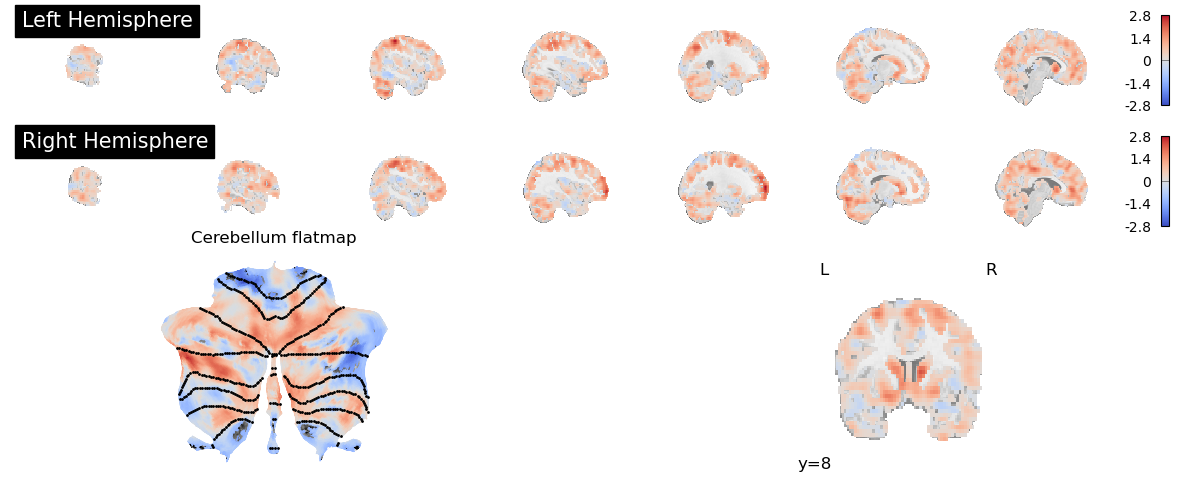

In [11]:
filename = data_dir+'/group/'+'adole_social_all_winVlos_intercept'

helpful_functions.plot_transparent_threshold(filename, thresh=.05)

#### Positive wins > Negative wins

/opt/anaconda3/lib/python3.11/site-packages/nilearn/plotting/displays/_slicers.py:366: UserWarning: empty mask
  self._map_show(img, type="contour", threshold=threshold, **kwargs)
/opt/anaconda3/lib/python3.11/site-packages/nilearn/plotting/displays/_slicers.py:366: UserWarning: empty mask
  self._map_show(img, type="contour", threshold=threshold, **kwargs)


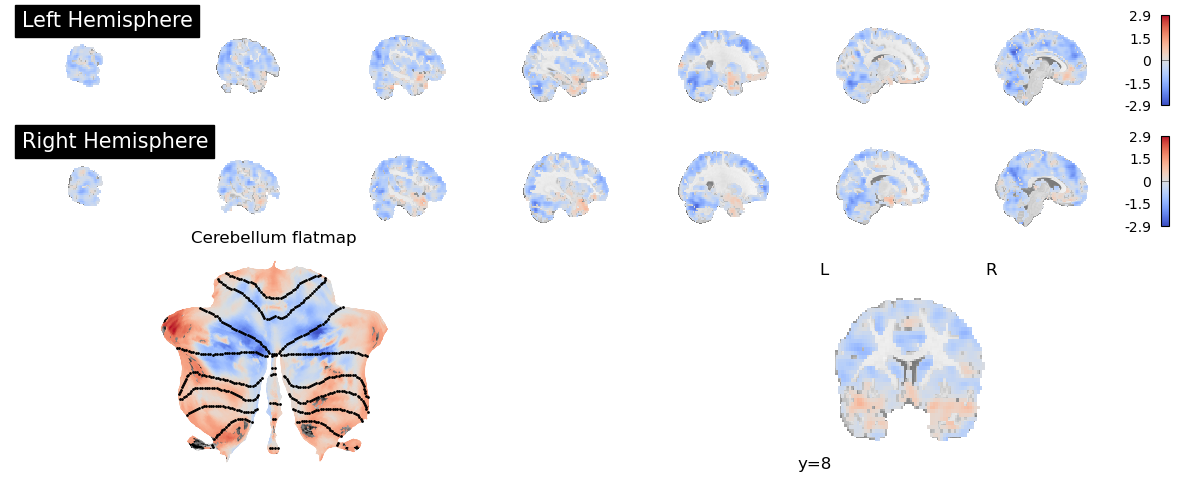

In [12]:
filename = data_dir+'/group/'+'adole_social_posVneg_win_intercept'

helpful_functions.plot_transparent_threshold(filename, thresh=.05)

## Young Adult Cohort

In [13]:
design_matrix = make_second_level_design_matrix(subjs_list_colg, subjs_info_colg_fltr)


contrasts = ['all_winVlos', 'positive_winVlos', 'negative_winVlos', 'posVneg_win']
contrasts_2nd = ['age','intercept']
tasks = ['mdoors','social']
group = 'adult'
mc = 'fdr'
alpha = 0.05


threshold_data = {}

for task in tasks:
    for contrast in contrasts:
        
        temp_file_list = []
        for subj in subjs_list_colg:
            temp_file = glob.glob(os.path.join(data_dir,subj,'zmap_'+task+'_'+contrast+'.nii.gz'))
            temp_file_list.append(temp_file[0])
        temp_file_list.sort()
        
        print('Calculating '+task+' group '+contrast+' contrast')
        
        model = SecondLevelModel(mask_img=mni_mask, smoothing_fwhm=8.0)
        model.fit(temp_file_list, design_matrix=design_matrix)
        
        for contrast_2nd in contrasts_2nd:
            # Compute a specific contrast (e.g. pos reward vs neg reward)
            contrast_stats = model.compute_contrast(contrast_2nd, output_type='all')
            
            # Save the z-score stat map and the effect size map
            z_map = contrast_stats['z_score']
            e_map = contrast_stats['effect_size']

            z_map.to_filename(os.path.join(data_dir,'group',
                                       group+'_'+task+'_'+contrast+'_'+contrast_2nd+'_zmap.nii.gz'))
            e_map.to_filename(os.path.join(data_dir,'group',
                                       group+'_'+task+'_'+contrast+'_'+contrast_2nd+'_effect.nii.gz'))

            
            # Multiple Comparisons Correction
            z_map_thresh, threshold = threshold_stats_img(z_map, alpha=alpha, height_control=mc)
            z_map_thresh.to_filename(os.path.join(data_dir,'group',
                                       group+'_'+task+'_'+contrast+'_'+contrast_2nd+'_zmap_'+mc+'-'+str(alpha)+'.nii.gz'))
            
            threshold_data['zmap_'+group+'_'+task+'_'+contrast+'_'+contrast_2nd+'_zmap_'+mc+'-'+str(alpha)] = threshold
            

/opt/anaconda3/lib/python3.11/site-packages/nilearn/glm/first_level/design_matrix.py:531: UserWarning: Attention: Design matrix is singular. Aberrant estimates are expected.
  warn(


Calculating mdoors group all_winVlos contrast


/opt/anaconda3/lib/python3.11/site-packages/nilearn/glm/thresholding.py:303: UserWarning: The given float value must not exceed 4.204329463075253. But, you have given threshold=inf.
  stat_img = threshold_img(
/opt/anaconda3/lib/python3.11/site-packages/nilearn/glm/thresholding.py:303: UserWarning: The given float value must not exceed 4.169309956152137. But, you have given threshold=inf.
  stat_img = threshold_img(


Calculating mdoors group positive_winVlos contrast


/opt/anaconda3/lib/python3.11/site-packages/nilearn/glm/thresholding.py:303: UserWarning: The given float value must not exceed 3.90884924247039. But, you have given threshold=inf.
  stat_img = threshold_img(
/opt/anaconda3/lib/python3.11/site-packages/nilearn/glm/thresholding.py:303: UserWarning: The given float value must not exceed 4.079303323655774. But, you have given threshold=inf.
  stat_img = threshold_img(


...

/opt/anaconda3/lib/python3.11/site-packages/nilearn/glm/thresholding.py:303: UserWarning: The given float value must not exceed 4.245465183603671. But, you have given threshold=inf.
  stat_img = threshold_img(
/opt/anaconda3/lib/python3.11/site-packages/nilearn/glm/thresholding.py:303: UserWarning: The given float value must not exceed 3.88876020799. But, you have given threshold=inf.
  stat_img = threshold_img(


Calculating social group negative_winVlos contrast


/opt/anaconda3/lib/python3.11/site-packages/nilearn/glm/thresholding.py:303: UserWarning: The given float value must not exceed 3.996183440142064. But, you have given threshold=inf.
  stat_img = threshold_img(
/opt/anaconda3/lib/python3.11/site-packages/nilearn/glm/thresholding.py:303: UserWarning: The given float value must not exceed 3.7625735947897594. But, you have given threshold=inf.
  stat_img = threshold_img(


Calculating social group posVneg_win contrast


/opt/anaconda3/lib/python3.11/site-packages/nilearn/glm/thresholding.py:303: UserWarning: The given float value must not exceed 4.445076928292857. But, you have given threshold=inf.
  stat_img = threshold_img(
/opt/anaconda3/lib/python3.11/site-packages/nilearn/glm/thresholding.py:303: UserWarning: The given float value must not exceed 4.475037023836049. But, you have given threshold=inf.
  stat_img = threshold_img(


### Monetary Task

#### Positive win > Positive loss

/opt/anaconda3/lib/python3.11/site-packages/nilearn/plotting/displays/_slicers.py:366: UserWarning: empty mask
  self._map_show(img, type="contour", threshold=threshold, **kwargs)
/opt/anaconda3/lib/python3.11/site-packages/nilearn/plotting/displays/_slicers.py:366: UserWarning: empty mask
  self._map_show(img, type="contour", threshold=threshold, **kwargs)


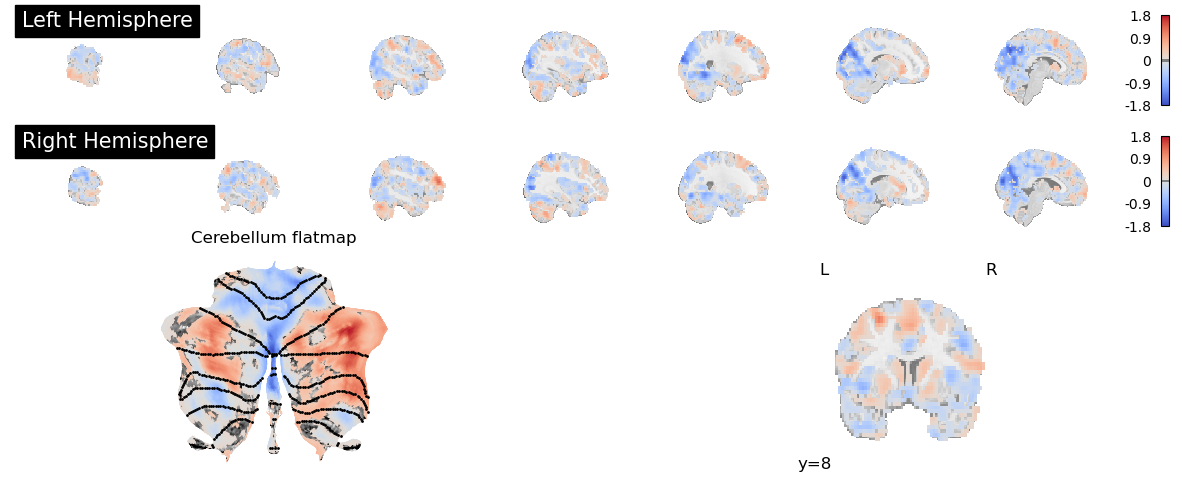

In [14]:
filename = data_dir+'/group/'+'adult_mdoors_positive_winVlos_intercept'

helpful_functions.plot_transparent_threshold(filename, thresh=.05)

#### All wins > All losses

/opt/anaconda3/lib/python3.11/site-packages/nilearn/plotting/displays/_slicers.py:366: UserWarning: empty mask
  self._map_show(img, type="contour", threshold=threshold, **kwargs)
/opt/anaconda3/lib/python3.11/site-packages/nilearn/plotting/displays/_slicers.py:366: UserWarning: empty mask
  self._map_show(img, type="contour", threshold=threshold, **kwargs)


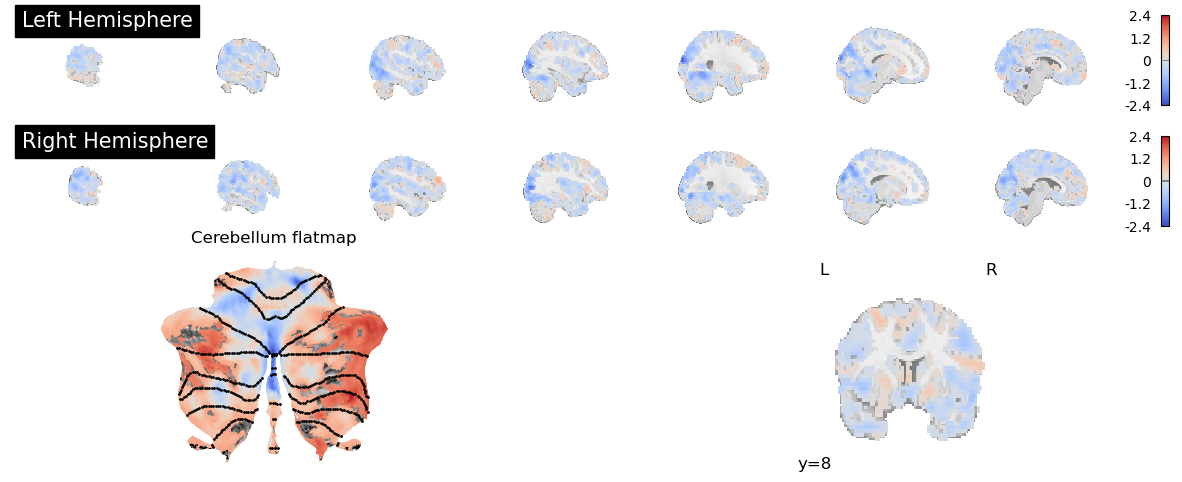

In [15]:
filename = data_dir+'/group/'+'adult_mdoors_all_winVlos_intercept'

helpful_functions.plot_transparent_threshold(filename, thresh=.05)

#### Positive wins > Negative wins

/opt/anaconda3/lib/python3.11/site-packages/nilearn/plotting/displays/_slicers.py:366: UserWarning: empty mask
  self._map_show(img, type="contour", threshold=threshold, **kwargs)
/opt/anaconda3/lib/python3.11/site-packages/nilearn/plotting/displays/_slicers.py:366: UserWarning: empty mask
  self._map_show(img, type="contour", threshold=threshold, **kwargs)


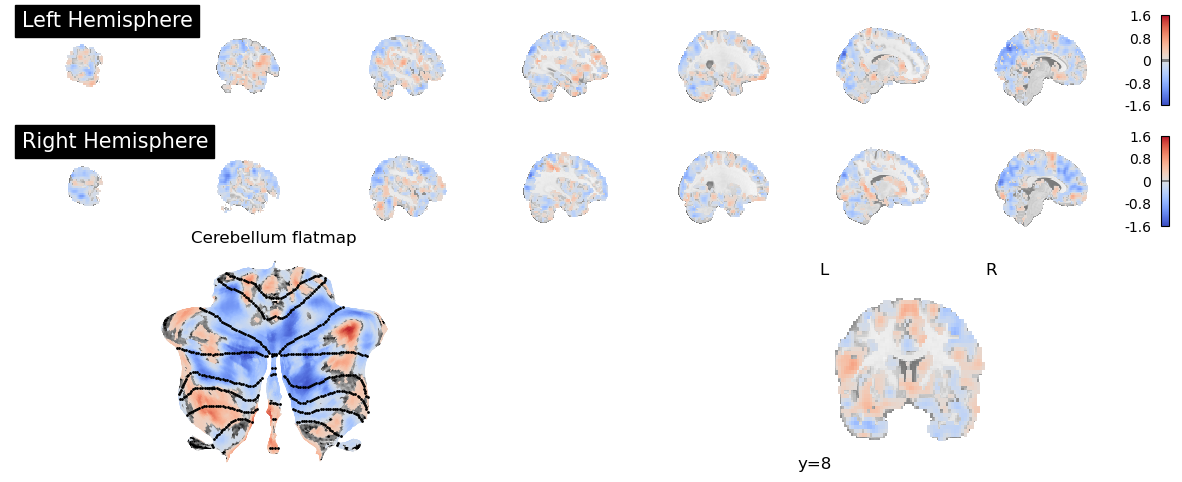

In [16]:
filename = data_dir+'/group/'+'adult_mdoors_posVneg_win_intercept'

helpful_functions.plot_transparent_threshold(filename, thresh=.05)

### Social Task

#### Positive win > Positive loss

/opt/anaconda3/lib/python3.11/site-packages/nilearn/plotting/displays/_slicers.py:366: UserWarning: empty mask
  self._map_show(img, type="contour", threshold=threshold, **kwargs)
/opt/anaconda3/lib/python3.11/site-packages/nilearn/plotting/displays/_slicers.py:366: UserWarning: empty mask
  self._map_show(img, type="contour", threshold=threshold, **kwargs)


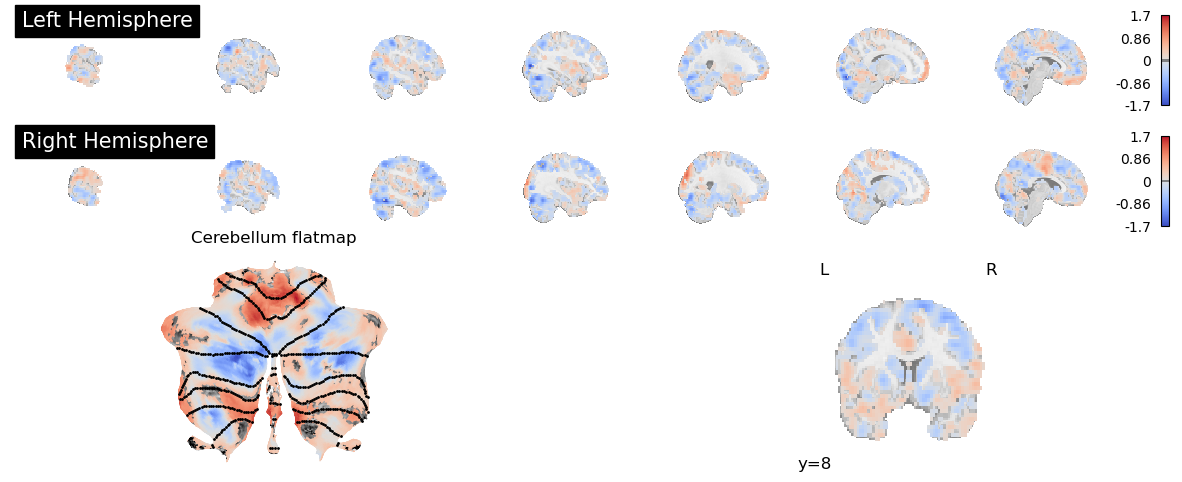

In [17]:
filename = data_dir+'/group/'+'adult_social_positive_winVlos_intercept'

helpful_functions.plot_transparent_threshold(filename, thresh=.05)

#### All wins > All losses

/opt/anaconda3/lib/python3.11/site-packages/nilearn/plotting/displays/_slicers.py:366: UserWarning: empty mask
  self._map_show(img, type="contour", threshold=threshold, **kwargs)
/opt/anaconda3/lib/python3.11/site-packages/nilearn/plotting/displays/_slicers.py:366: UserWarning: empty mask
  self._map_show(img, type="contour", threshold=threshold, **kwargs)


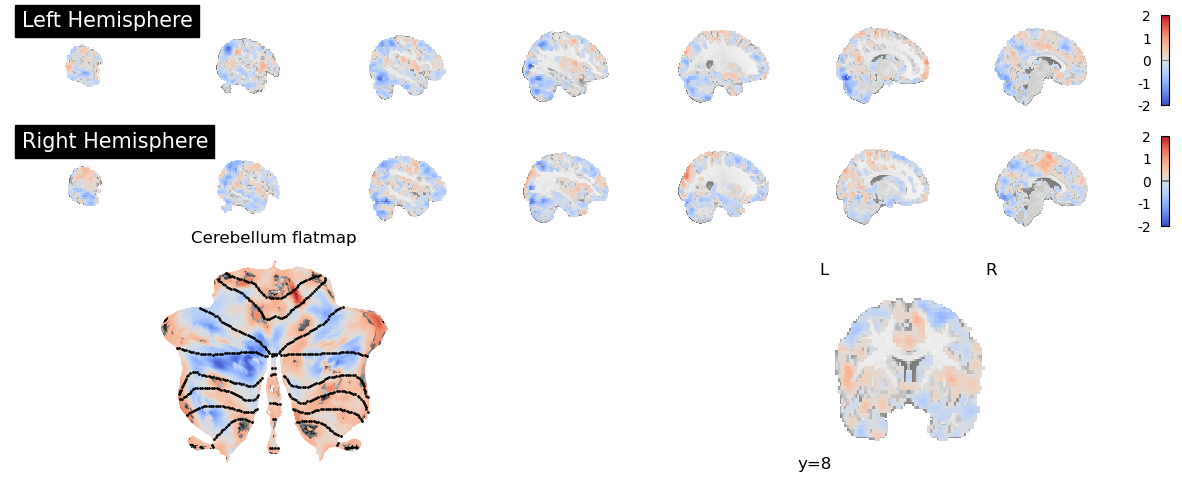

In [18]:
filename = data_dir+'/group/'+'adult_social_all_winVlos_intercept'

helpful_functions.plot_transparent_threshold(filename, thresh=.05)

### Positive wins > Negative wins

/opt/anaconda3/lib/python3.11/site-packages/nilearn/plotting/displays/_slicers.py:366: UserWarning: empty mask
  self._map_show(img, type="contour", threshold=threshold, **kwargs)
/opt/anaconda3/lib/python3.11/site-packages/nilearn/plotting/displays/_slicers.py:366: UserWarning: empty mask
  self._map_show(img, type="contour", threshold=threshold, **kwargs)


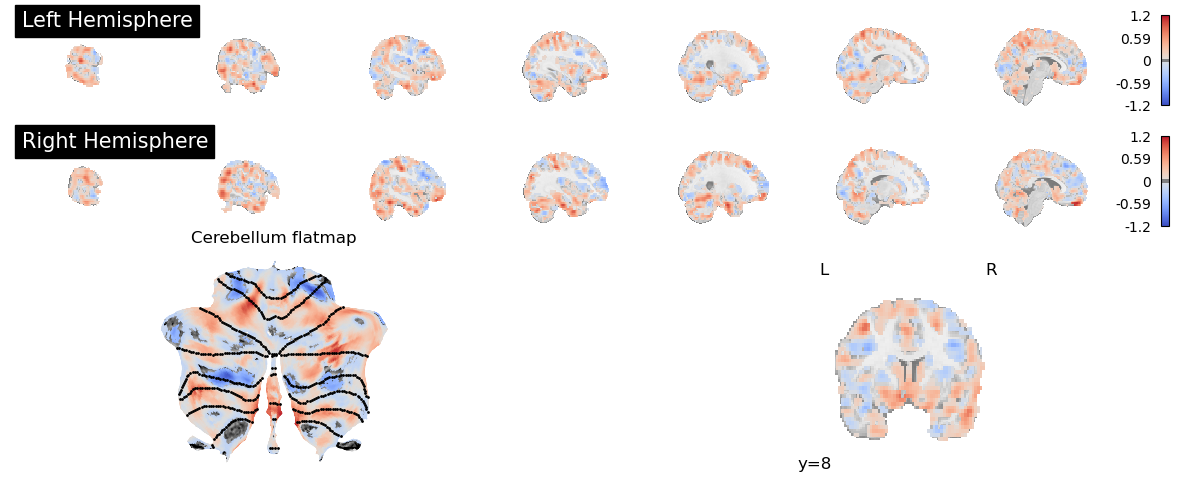

In [19]:
filename = data_dir+'/group/'+'adult_social_posVneg_win_intercept'

helpful_functions.plot_transparent_threshold(filename, thresh=.05)

# All Subjects

/var/folders/bj/bjn1471s0735c7771plnzsz00000gn/T/ipykernel_7253/4178790924.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  subjs_info_num = subjs_info_num.replace({'sex': {'F': 0, 'M': 1},


<Axes: label='conditions', ylabel='scan number'>

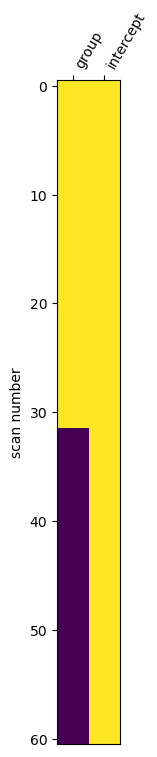

In [20]:
subjs_info_num = subjs_info.copy()
subjs_info_num = subjs_info_num.replace({'sex': {'F': 0, 'M': 1},
                                         'group': {'college': -1, 'kid': 1}})
subjs_info_num = subjs_info_num.drop(columns=['age', 'sex'])

design_matrix = make_second_level_design_matrix(subjs_list, subjs_info_num)

plot_design_matrix(design_matrix)

In [22]:
#design_matrix = make_second_level_design_matrix(subjs_list, subjs_info_fltr)

#contrasts = ['valence_x_outcome',
#             'positive','positive_win','positive_loss',
#             'negative','negative_win','negative_loss']
contrasts = ['all_winVlos', 'positive_winVlos', 'negative_winVlos', 'posVneg_win']
contrasts_2nd = ['intercept','group']
tasks = ['mdoors','social']
group = 'all'
mc = 'fdr'
alpha = 0.05

threshold_all = {}

#temp_file_list = []
#for subj in subjs_list_kids:
#    temp_file = glob.glob(os.path.join(data_dir,subj,'zmap_'+task+'_'+contrast+'.nii.gz'))
#    temp_file_list.append(temp_file[0])
for task in tasks:
    for contrast in contrasts:
        
        temp_file_list = []
        for subj in subjs_list:
            temp_file = glob.glob(os.path.join(data_dir,subj,'zmap_'+task+'_'+contrast+'.nii.gz'))
            temp_file_list.append(temp_file[0])
        temp_file_list.sort()
        
        print('Calculating '+task+' '+group+' '+contrast+' contrast')
        
        model = SecondLevelModel(mask_img=mni_mask, smoothing_fwhm=8.0)
        model.fit(temp_file_list, design_matrix=design_matrix)
        
        for contrast_2nd in contrasts_2nd:
            # Compute a specific contrast (e.g. pos reward vs neg reward)
            contrast_stats = model.compute_contrast(contrast_2nd, output_type='all')
            
            # Save the z-score stat map and the effect size map
            z_map = contrast_stats['z_score']
            e_map = contrast_stats['effect_size']

            z_map.to_filename(os.path.join(data_dir,'group',
                                       group+'_'+task+'_'+contrast+'_'+contrast_2nd+'_zmap.nii.gz'))
            e_map.to_filename(os.path.join(data_dir,'group',
                                       group+'_'+task+'_'+contrast+'_'+contrast_2nd+'_effect.nii.gz'))

            
            # Multiple Comparisons Correction
            z_map_thresh, threshold = threshold_stats_img(z_map, alpha=alpha, height_control=mc)
            z_map_thresh.to_filename(os.path.join(data_dir,'group',
                                       group+'_'+task+'_'+contrast+'_'+contrast_2nd+'_zmap_'+mc+'-'+str(alpha)+'.nii.gz'))
            
            threshold_data['zmap_'+group+'_'+task+'_'+contrast+'_'+contrast_2nd+'_zmap_'+mc+'-'+str(alpha)] = threshold
            

Calculating mdoors all all_winVlos contrast


/opt/anaconda3/lib/python3.11/site-packages/nilearn/glm/thresholding.py:303: UserWarning: The given float value must not exceed 3.4064298733536873. But, you have given threshold=inf.
  stat_img = threshold_img(


Calculating mdoors all positive_winVlos contrast


/opt/anaconda3/lib/python3.11/site-packages/nilearn/glm/thresholding.py:303: UserWarning: The given float value must not exceed 3.441156930114357. But, you have given threshold=inf.
  stat_img = threshold_img(


Calculating mdoors all negative_winVlos contrast


...

/opt/anaconda3/lib/python3.11/site-packages/nilearn/glm/thresholding.py:303: UserWarning: The given float value must not exceed 4.383522033054729. But, you have given threshold=inf.
  stat_img = threshold_img(


Calculating social all positive_winVlos contrast
Calculating social all negative_winVlos contrast


/opt/anaconda3/lib/python3.11/site-packages/nilearn/glm/thresholding.py:303: UserWarning: The given float value must not exceed 3.410032676548574. But, you have given threshold=inf.
  stat_img = threshold_img(


Calculating social all posVneg_win contrast


/opt/anaconda3/lib/python3.11/site-packages/nilearn/glm/thresholding.py:303: UserWarning: The given float value must not exceed 3.5536499599149383. But, you have given threshold=inf.
  stat_img = threshold_img(


## Group differences 
Where adolescents > young adults

### Monetary Task

#### Positive win > Positive loss

/opt/anaconda3/lib/python3.11/site-packages/nilearn/plotting/displays/_slicers.py:366: UserWarning: empty mask
  self._map_show(img, type="contour", threshold=threshold, **kwargs)
/opt/anaconda3/lib/python3.11/site-packages/nilearn/plotting/displays/_slicers.py:366: UserWarning: empty mask
  self._map_show(img, type="contour", threshold=threshold, **kwargs)


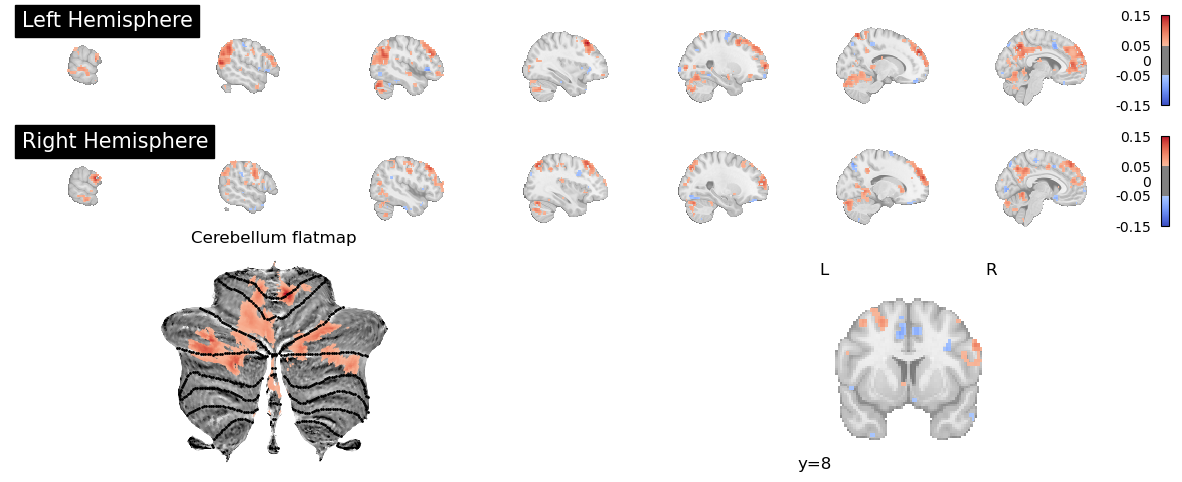

In [23]:
filename = data_dir+'/group/'+'all_mdoors_positive_winVlos_group'

helpful_functions.plot_transparent_threshold(filename, thresh=.05)

#### All wins > All losses

/opt/anaconda3/lib/python3.11/site-packages/nilearn/plotting/displays/_slicers.py:366: UserWarning: empty mask
  self._map_show(img, type="contour", threshold=threshold, **kwargs)
/opt/anaconda3/lib/python3.11/site-packages/nilearn/plotting/displays/_slicers.py:366: UserWarning: empty mask
  self._map_show(img, type="contour", threshold=threshold, **kwargs)


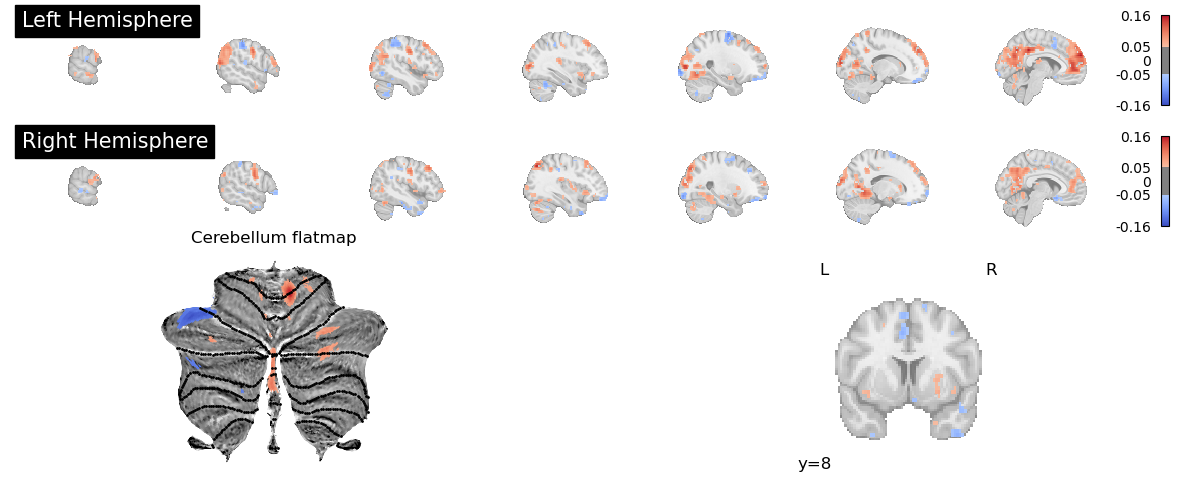

In [24]:
filename = data_dir+'/group/'+'all_mdoors_all_winVlos_group'

helpful_functions.plot_transparent_threshold(filename, thresh=.05)

### Positive win > Negative win

/opt/anaconda3/lib/python3.11/site-packages/nilearn/plotting/displays/_slicers.py:366: UserWarning: empty mask
  self._map_show(img, type="contour", threshold=threshold, **kwargs)
/opt/anaconda3/lib/python3.11/site-packages/nilearn/plotting/displays/_slicers.py:366: UserWarning: empty mask
  self._map_show(img, type="contour", threshold=threshold, **kwargs)


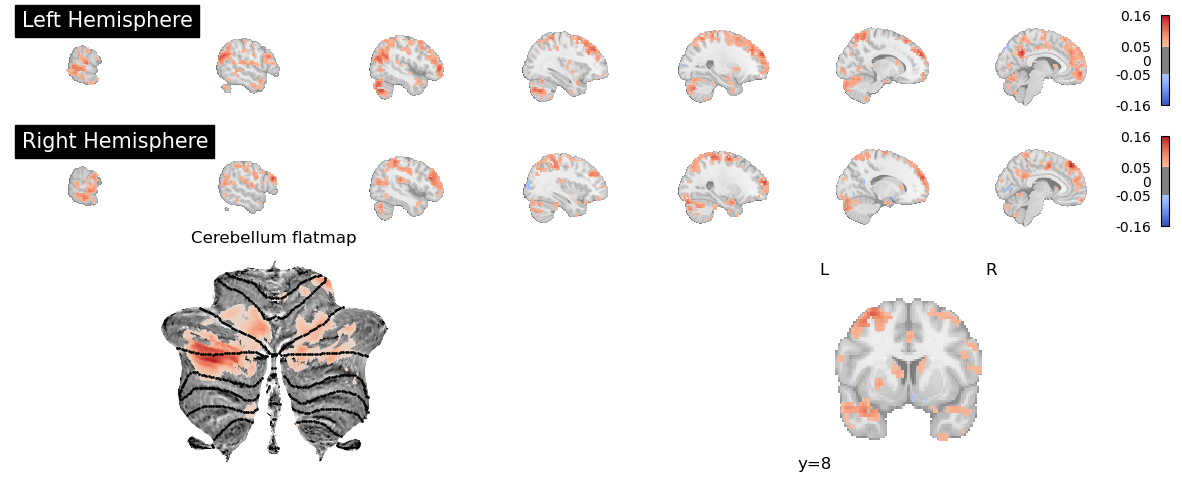

In [25]:
filename = data_dir+'/group/'+'all_mdoors_posVneg_win_group'

helpful_functions.plot_transparent_threshold(filename, thresh=.05)

### Social Task

#### Positive win > Positive loss

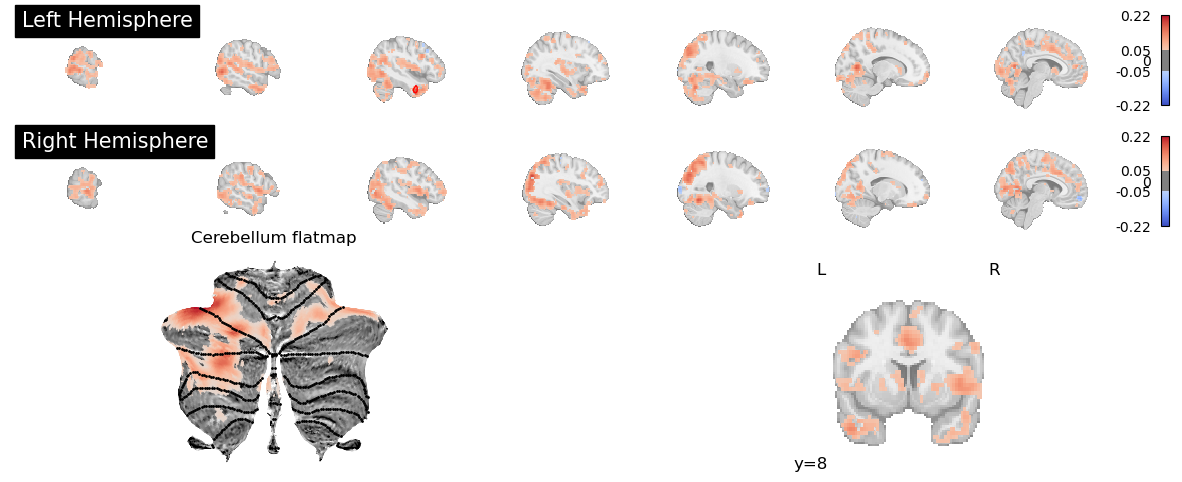

In [26]:
filename = data_dir+'/group/'+'all_social_positive_winVlos_group'

helpful_functions.plot_transparent_threshold(filename, thresh=.05)

#### All wins > All losses

/opt/anaconda3/lib/python3.11/site-packages/nilearn/plotting/displays/_slicers.py:366: UserWarning: empty mask
  self._map_show(img, type="contour", threshold=threshold, **kwargs)
/opt/anaconda3/lib/python3.11/site-packages/nilearn/plotting/displays/_slicers.py:366: UserWarning: empty mask
  self._map_show(img, type="contour", threshold=threshold, **kwargs)


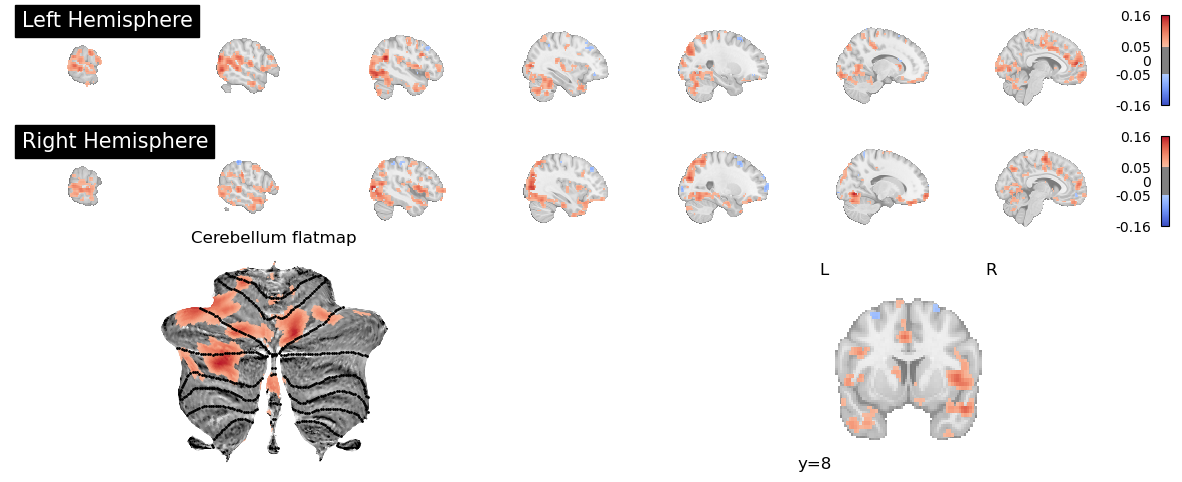

In [27]:
filename = data_dir+'/group/'+'all_social_all_winVlos_group'

helpful_functions.plot_transparent_threshold(filename, thresh=.05)

### Positive win > Negative win

/opt/anaconda3/lib/python3.11/site-packages/nilearn/plotting/displays/_slicers.py:366: UserWarning: empty mask
  self._map_show(img, type="contour", threshold=threshold, **kwargs)
/opt/anaconda3/lib/python3.11/site-packages/nilearn/plotting/displays/_slicers.py:366: UserWarning: empty mask
  self._map_show(img, type="contour", threshold=threshold, **kwargs)


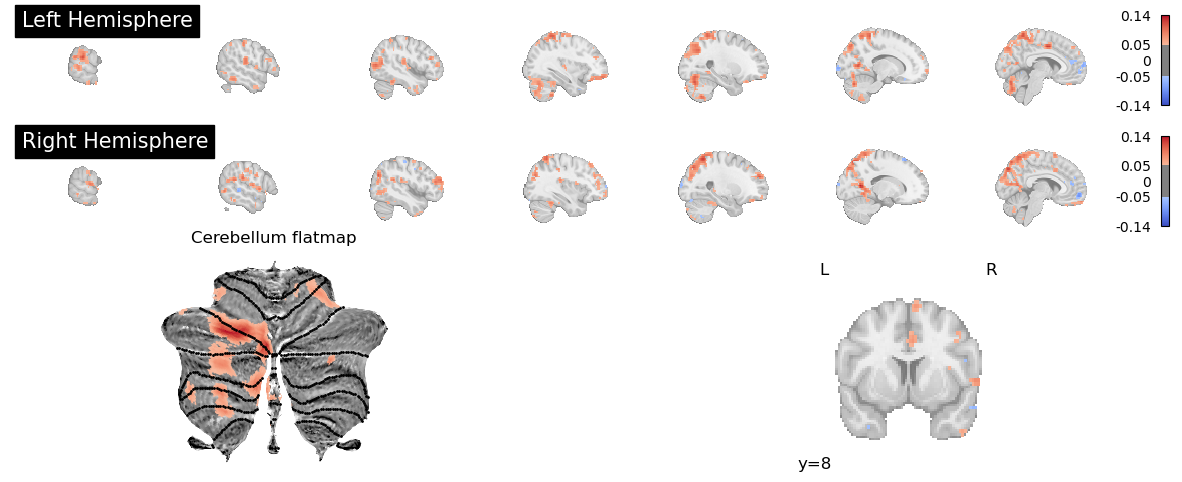

In [28]:
filename = data_dir+'/group/'+'all_social_posVneg_win_group'

helpful_functions.plot_transparent_threshold(filename, thresh=.05)

## Accounting for Group

### Monetary Task

#### Positive win > Positive loss

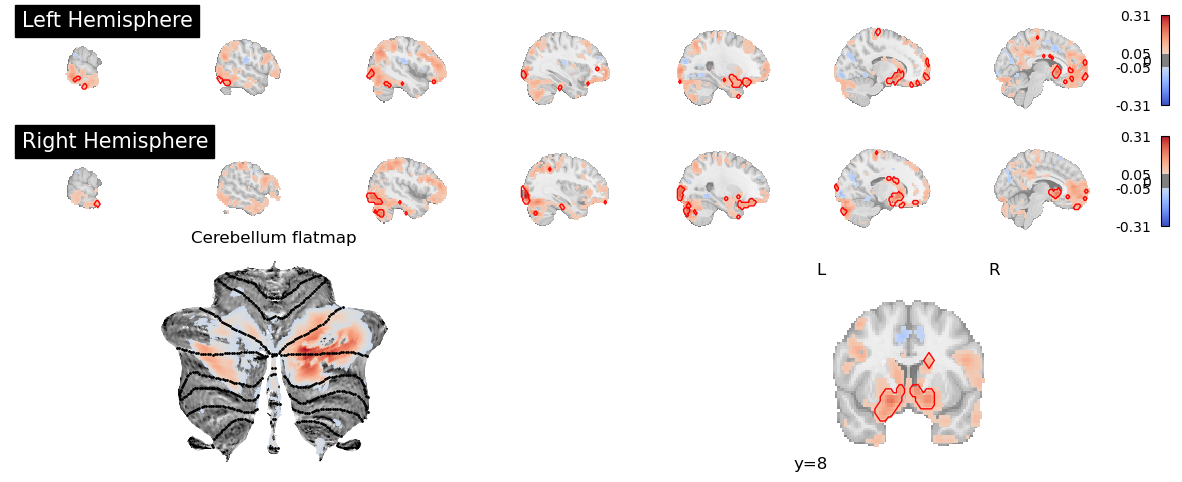

In [31]:
filename = data_dir+'/group/'+'all_mdoors_positive_winVlos_intercept'

helpful_functions.plot_transparent_threshold(filename, thresh=.05)

#### All wins > All losses

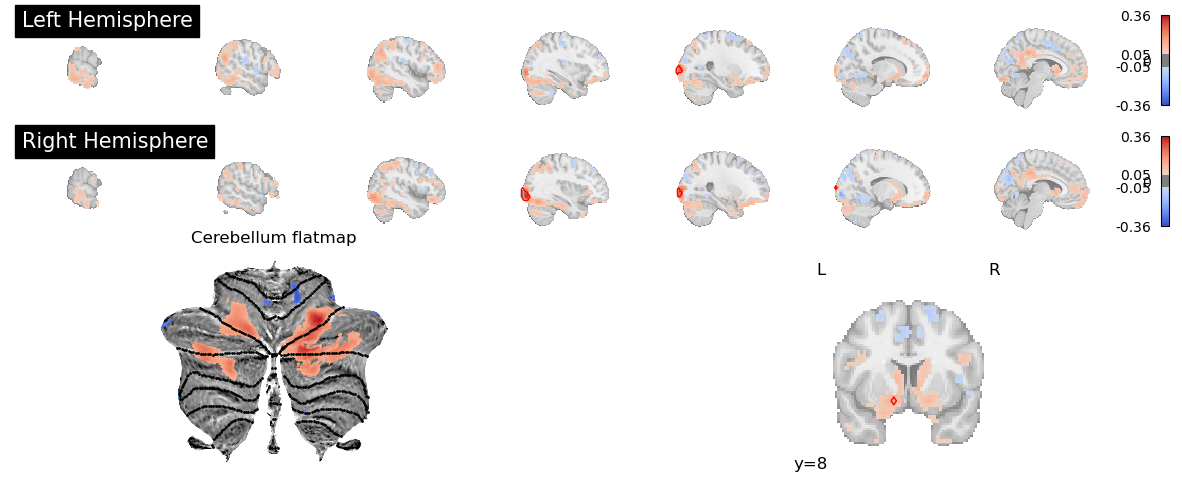

In [32]:
filename = data_dir+'/group/'+'all_mdoors_all_winVlos_intercept'

helpful_functions.plot_transparent_threshold(filename, thresh=.05)

In [ ]:
### Positive win > Negative win

/opt/anaconda3/lib/python3.11/site-packages/nilearn/plotting/displays/_slicers.py:366: UserWarning: empty mask
  self._map_show(img, type="contour", threshold=threshold, **kwargs)
/opt/anaconda3/lib/python3.11/site-packages/nilearn/plotting/displays/_slicers.py:366: UserWarning: empty mask
  self._map_show(img, type="contour", threshold=threshold, **kwargs)


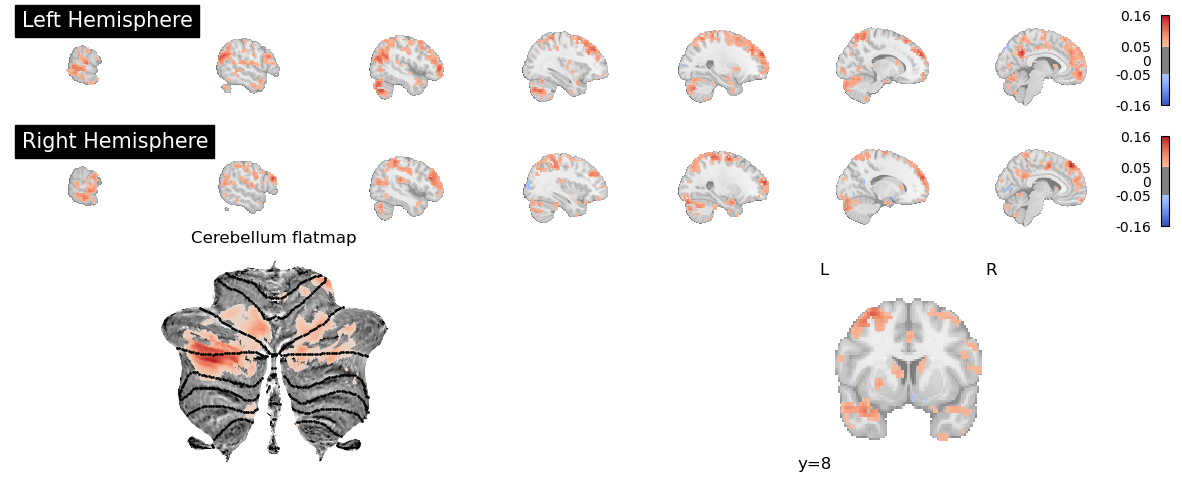

In [33]:
filename = data_dir+'/group/'+'all_mdoors_posVneg_win_group'

helpful_functions.plot_transparent_threshold(filename, thresh=.05)

### Social Task

#### Positive wins > Positive losses

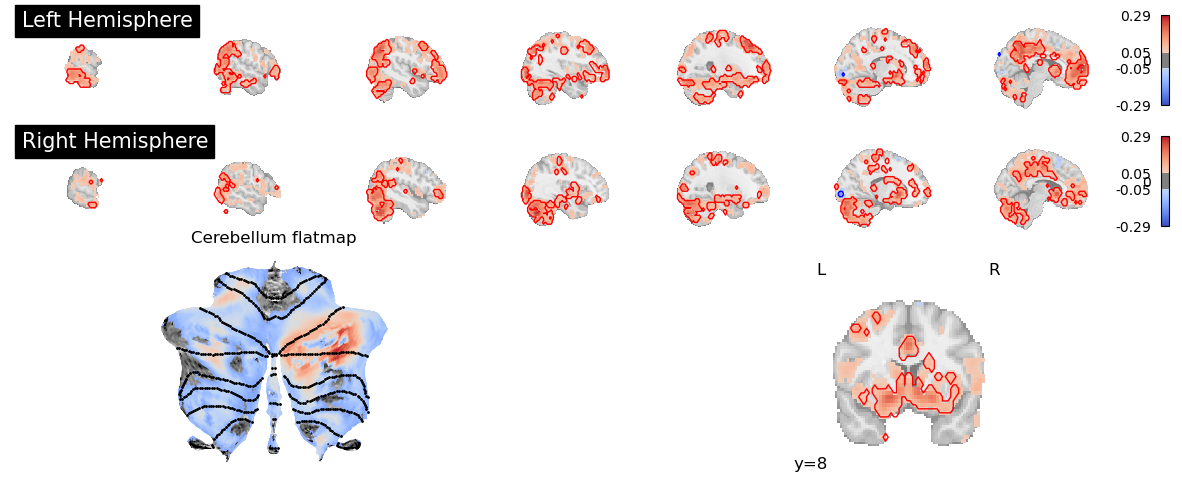

In [34]:
filename = data_dir+'/group/'+'all_social_positive_winVlos_intercept'

helpful_functions.plot_transparent_threshold(filename, thresh=.05)

#### All wins > All losses

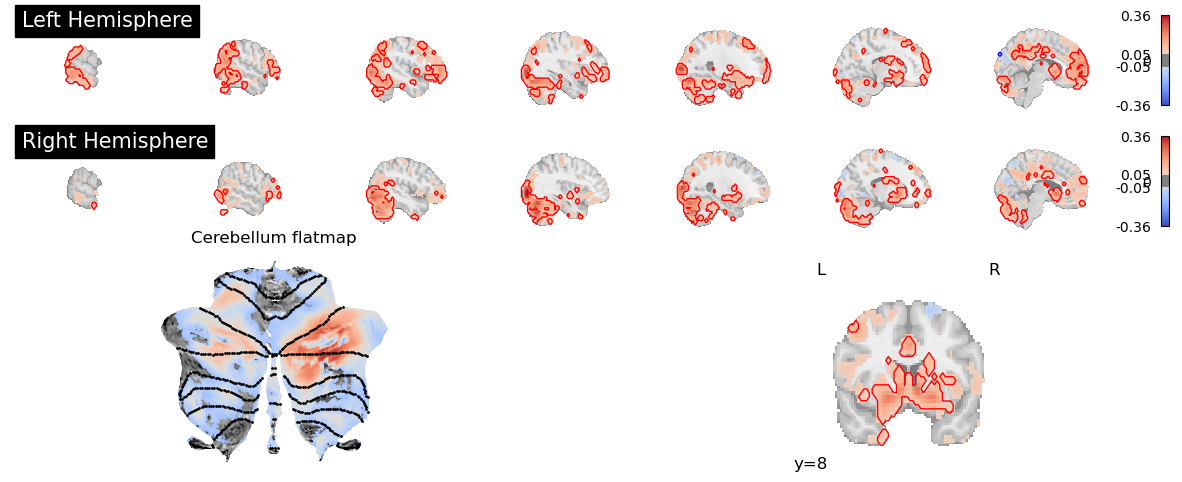

In [35]:
filename = data_dir+'/group/'+'all_social_all_winVlos_intercept'

helpful_functions.plot_transparent_threshold(filename, thresh=.05)

### Positive win > Negative win

/opt/anaconda3/lib/python3.11/site-packages/nilearn/plotting/displays/_slicers.py:366: UserWarning: empty mask
  self._map_show(img, type="contour", threshold=threshold, **kwargs)
/opt/anaconda3/lib/python3.11/site-packages/nilearn/plotting/displays/_slicers.py:366: UserWarning: empty mask
  self._map_show(img, type="contour", threshold=threshold, **kwargs)


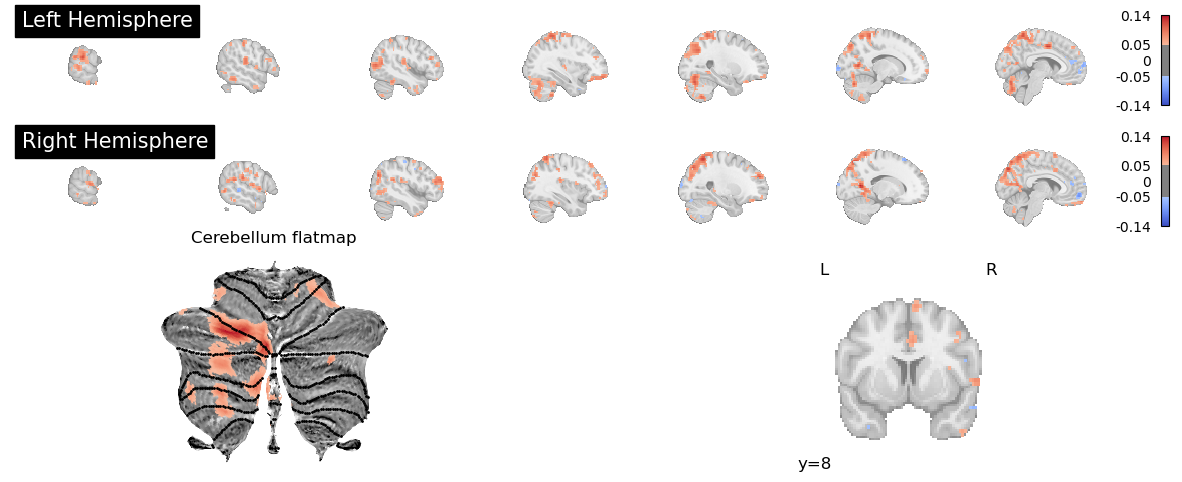

In [36]:
filename = data_dir+'/group/'+'all_social_posVneg_win_group'

helpful_functions.plot_transparent_threshold(filename, thresh=.05)

# Behavioral Analysis

Not updated

In [62]:
behav_data = pd.read_excel(bids_dir+'/derivatives/behavioral/aggregate_full_data_SPSS_020419.xlsx',
                          sheet_name='Sheet1')

behav_data.head()

,Order,Subject,ch_totanx,ch_socialanx,p_totanx,p_socialanx,bfne,ch_cdi_total,ch_cdi_interpersonal,ch_cdi_anhedonia,...,FB_VS_6mm_R_Like_Lose_NZMean_1,FB_VS_6mm_R_Like_Lose_NZCount_1,FB_VS_6mm_R_Like_Lose_NZMin_1,FB_VS_6mm_R_Like_Lose_NZMax_1,FB_VS_6mm_R_Like_Win_Mean_1,FB_VS_6mm_R_Like_Win_NZMean_1,FB_VS_6mm_R_Like_Win_NZCount_1,FB_VS_6mm_R_Like_Win_NZMin_1,FB_VS_6mm_R_Like_Win_NZMax_1,FB_VS6mm_L_Correct_DislikeVsLike
0,1,s010,51,14,7,1,33,11.0,0.0,5.0,...,0.029036,123.0,-0.296210,0.647286,0.256033,0.256033,123.0,-0.022722,0.752379,-0.127002
1,1,s011,12,3,4,1,31,8.0,0.0,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,s013,8,4,1,1,13,5.0,0.0,2.0,...,-0.308424,123.0,-0.554069,0.030482,0.093248,0.093248,123.0,-0.183241,1.003483,-0.167305
3,1,s015,18,5,1,0,21,NaN,NaN,NaN,...,-0.798996,123.0,-1.841710,-0.031699,0.004660,0.004660,123.0,-1.020790,0.809193,0.485397
4,2,s024,21,10,0,0,28,1.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [63]:
behav_data_fltr = behav_data[['Subject','ch_totanx', 'ch_cdi_total']]

behav_data_fltr['Subject'] = behav_data_fltr['Subject'].str.replace('s','sub-')

behav_data_fltr = behav_data_fltr.rename(columns={'Subject':'subject_label'})

behav_data_fltr.head()

/Users/haroonpopal/anaconda3/envs/py37/lib/python3.7/site-packages/ipykernel_launcher.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  This is separate from the ipykernel package so we can avoid doing imports until


,subject_label,ch_totanx,ch_cdi_total
0,sub-010,51,11.0
1,sub-011,12,8.0
2,sub-013,8,5.0
3,sub-015,18,NaN
4,sub-024,21,1.0


/Users/haroonpopal/anaconda3/envs/py37/lib/python3.7/site-packages/nilearn/glm/first_level/design_matrix.py:475: UserWarning: Attention: Design matrix is singular. Aberrant estimates are expected.
  warn('Attention: Design matrix is singular. Aberrant estimates '


<AxesSubplot:label='conditions', ylabel='scan number'>

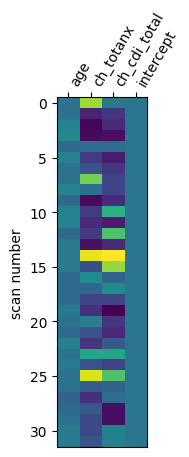

In [64]:
# Add behavioral data to design matrix

subjs_info_kids_behav = subjs_info_kids_fltr.merge(behav_data_fltr, on='subject_label')


design_matrix = make_second_level_design_matrix(subjs_list_kids, subjs_info_kids_behav)

plot_design_matrix(design_matrix)

In [65]:
#design_matrix = make_second_level_design_matrix(subjs_list_kids, subjs_info_kids_fltr)
mni_mask = bids_dir+"/derivatives/fmriprep/sub-010/anat/sub-010_space-MNI152NLin2009cAsym_label-GM_probseg_bin.nii.gz"

#contrasts = ['valence_x_outcome',
#             'positive','positive_win','positive_loss',
#             'negative','negative_win','negative_loss']
contrasts=['all_winVlos', 'positive_winVlos']
contrasts_2nd = ['ch_totanx','ch_cdi_total']
tasks = ['mdoors','social']
group = 'kids'
alpha = 0.001


threshold_data = {}

for task in tasks:
    for contrast in contrasts:
        
        temp_file_list = []
        for subj in subjs_list_kids:
            temp_file = glob.glob(os.path.join(data_dir,subj,'zmap_'+task+'_'+contrast+'.nii'))
            temp_file_list.append(temp_file[0])
        temp_file_list.sort()
        
        print('Calculating '+task+' group '+contrast+' contrast')
        
        model = SecondLevelModel(mask_img=mni_mask, smoothing_fwhm=8.0)
        model.fit(temp_file_list, design_matrix=design_matrix)
        
        for contrast_2nd in contrasts_2nd:
            z_map = model.compute_contrast(contrast_2nd, output_type='z_score')

            z_map.to_filename(os.path.join(data_dir,'group',
                                       'zmap_'+group+'_'+task+'_'+contrast+'_'+contrast_2nd+'_unc.nii.gz'))
            
            # Multiple Comparisons Correction
            z_map_thresh, threshold = threshold_stats_img(z_map, alpha=alpha, height_control='fpr')
            z_map_thresh.to_filename(os.path.join(data_dir,'group',
                                       'zmap_'+group+'_'+task+'_'+contrast+'_'+contrast_2nd+'_fpr.nii.gz'))
            
            threshold_data['zmap_'+group+'_'+task+'_'+contrast+'_'+contrast_2nd+'_fpr_'+str(alpha)] = threshold

Calculating mdoors group all_winVlos contrast
Calculating mdoors group positive_winVlos contrast
Calculating social group all_winVlos contrast
Calculating social group positive_winVlos contrast


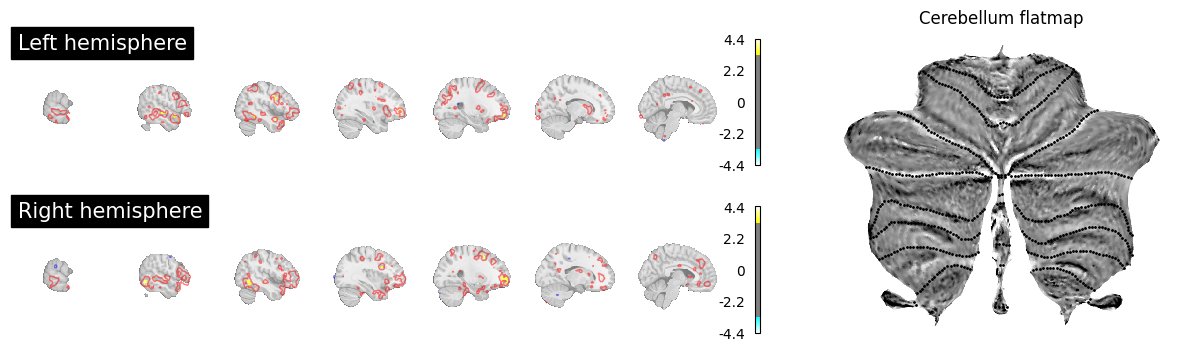

In [70]:
filename = 'zmap_kids_social_positive_winVlos_ch_cdi_total_'
threshold = threshold_data[filename+'fpr_'+str(alpha)]
#threshold=1

plot_stat_map_cb(filename+'unc', threshold)

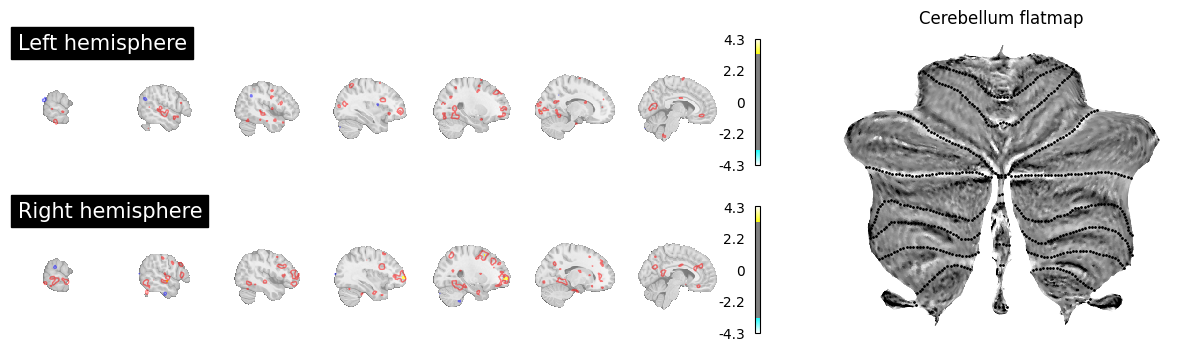

In [69]:
filename = 'zmap_kids_social_all_winVlos_ch_cdi_total_'
threshold = threshold_data[filename+'fpr_'+str(alpha)]
#threshold=1

plot_stat_map_cb(filename+'unc', threshold)